# Dhumbal: Figure Generation

This notebook regenerates every figure used in the manuscript directly from the result files under `agents/`, `championship/`, and the learning-agent training logs. Running all cells writes the figures to `visualization/plots/`.

In [36]:
# Shared setup: imports, paths, and publication styling for all figures.
import os, glob, json, warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
warnings.filterwarnings('ignore')

# Resolve the repository root whether this notebook is run from the repo
# root or from the visualization/ directory.
_here = os.getcwd()
ROOT = os.path.dirname(_here) if os.path.basename(_here) == 'visualization' else _here
PLOTS = os.path.join(ROOT, 'visualization', 'plots')
os.makedirs(PLOTS, exist_ok=True)

rcParams['font.family'] = 'Times New Roman'
rcParams['font.size'] = 10
rcParams['figure.dpi'] = 300
rcParams['savefig.dpi'] = 300
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['axes.linewidth'] = 0.8


## Rule-based agents: within-category tournament

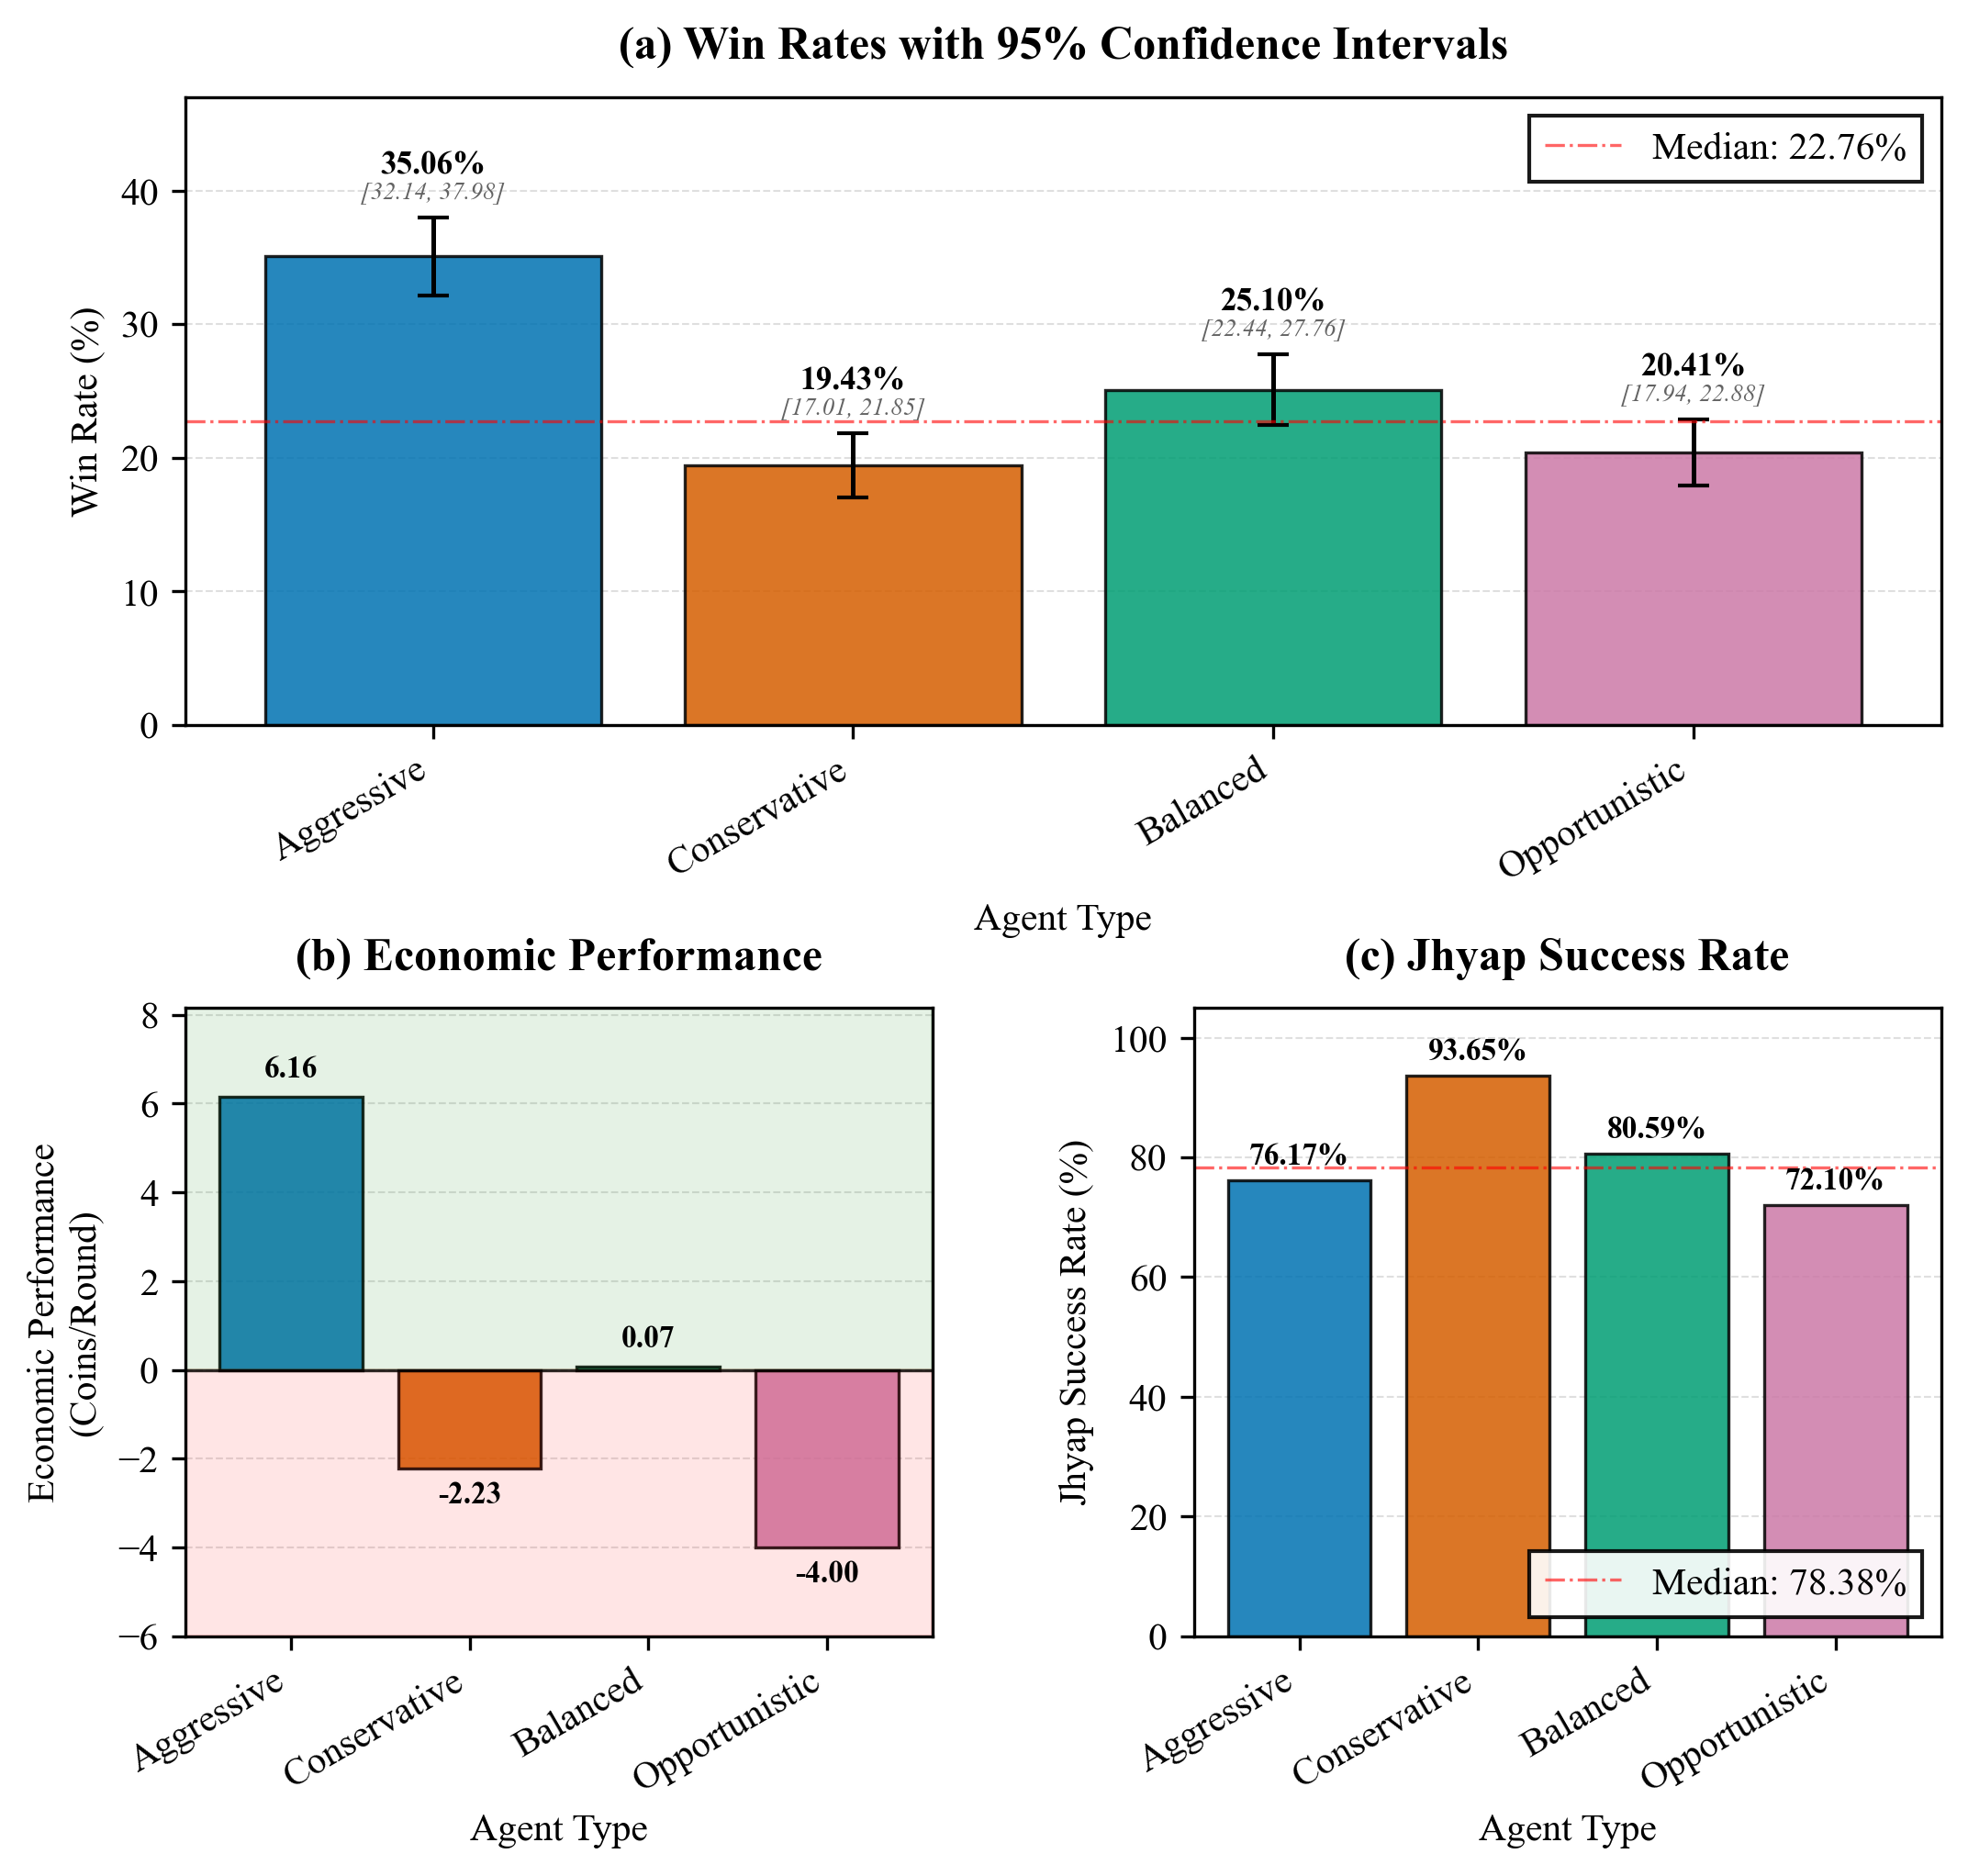

saved /Users/sahajrajmalla/Documents/dhumbal-ai/visualization/plots/rule_based_plots_enhanced.png


In [37]:
# Rule-based within-category tournament (4-player, 1024 rounds).
# Source: agents/rule_based/metrics.csv
colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']
agents = ['Aggressive', 'Conservative', 'Balanced', 'Opportunistic']
win_rates = [35.06, 19.43, 25.10, 20.41]
win_ci_lower = [32.14, 17.01, 22.44, 17.94]
win_ci_upper = [37.98, 21.85, 27.76, 22.88]
economic_means = [6.16, -2.23, 0.07, -4.00]
jhyap_success = [76.17, 93.65, 80.59, 72.10]
ci_errors = [[win_rates[i]-win_ci_lower[i] for i in range(4)],
             [win_ci_upper[i]-win_rates[i] for i in range(4)]]
fig = plt.figure(figsize=(7.5, 6.5))
gs = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.35, left=0.1, right=0.95, top=0.94, bottom=0.08)
ax1 = fig.add_subplot(gs[0, :]); ax2 = fig.add_subplot(gs[1, 0]); ax3 = fig.add_subplot(gs[1, 1])
b1 = ax1.bar(agents, win_rates, yerr=ci_errors, capsize=4, color=colors, edgecolor='black',
             linewidth=0.8, alpha=0.85, error_kw={'linewidth': 1.2})
ax1.set_ylabel('Win Rate (%)'); ax1.set_xlabel('Agent Type')
ax1.set_title('(a) Win Rates with 95% Confidence Intervals', fontweight='bold', pad=10)
ax1.set_ylim(0, 47); ax1.grid(True, axis='y', linestyle='--', alpha=0.4, linewidth=0.5); ax1.set_axisbelow(True)
for bar, rate, lo, hi in zip(b1, win_rates, win_ci_lower, win_ci_upper):
    x = bar.get_x()+bar.get_width()/2.
    # Stack both labels clearly ABOVE the error-bar cap (top = hi) to avoid overlap.
    ax1.text(x, hi+1.0, f'[{lo:.2f}, {hi:.2f}]', ha='center', va='bottom', fontsize=6.5, style='italic', color='#636363')
    ax1.text(x, hi+2.7, f'{rate:.2f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
mw = np.median(win_rates)
ax1.axhline(mw, color='red', linestyle='-.', linewidth=0.8, alpha=0.6, label=f'Median: {mw:.2f}%')
ax1.legend(loc='upper right', framealpha=0.9, edgecolor='black', fancybox=False)
b2 = ax2.bar(agents, economic_means, color=colors, edgecolor='black', linewidth=0.8, alpha=0.85)
ax2.set_ylabel('Economic Performance\n(Coins/Round)'); ax2.set_xlabel('Agent Type')
ax2.set_title('(b) Economic Performance', fontweight='bold', pad=10)
ax2.axhline(0, color='black', linewidth=0.8, alpha=0.8)
ax2.grid(True, axis='y', linestyle='--', alpha=0.4, linewidth=0.5); ax2.set_axisbelow(True)
ymin, ymax = min(economic_means)-2, max(economic_means)+2; ax2.set_ylim(ymin, ymax)
for bar, v in zip(b2, economic_means):
    h = bar.get_height(); va = 'bottom' if h >= 0 else 'top'; yp = h+0.3 if h >= 0 else h-0.3
    ax2.text(bar.get_x()+bar.get_width()/2., yp, f'{v:.2f}', ha='center', va=va, fontsize=8, fontweight='bold')
ax2.axhspan(0, ymax, alpha=0.1, color='green'); ax2.axhspan(ymin, 0, alpha=0.1, color='red')
b3 = ax3.bar(agents, jhyap_success, color=colors, edgecolor='black', linewidth=0.8, alpha=0.85)
ax3.set_ylabel('Jhyap Success Rate (%)'); ax3.set_xlabel('Agent Type')
ax3.set_title('(c) Jhyap Success Rate', fontweight='bold', pad=10); ax3.set_ylim(0, 105)
ax3.grid(True, axis='y', linestyle='--', alpha=0.4, linewidth=0.5); ax3.set_axisbelow(True)
for bar, v in zip(b3, jhyap_success):
    ax3.text(bar.get_x()+bar.get_width()/2., bar.get_height()+1.5, f'{v:.2f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
mj = np.median(jhyap_success)
ax3.axhline(mj, color='red', linestyle='-.', linewidth=0.8, alpha=0.6, label=f'Median: {mj:.2f}%')
ax3.legend(loc='lower right', framealpha=0.9, edgecolor='black', fancybox=False)
for ax in [ax1, ax2, ax3]:
    ax.set_xticklabels(agents, rotation=30, ha='right')
out = os.path.join(PLOTS, 'rule_based_plots_enhanced.png')
plt.savefig(out, dpi=300, bbox_inches='tight'); plt.show()
print('saved', out)


## Rule-based agents: pairwise effect-size heatmap

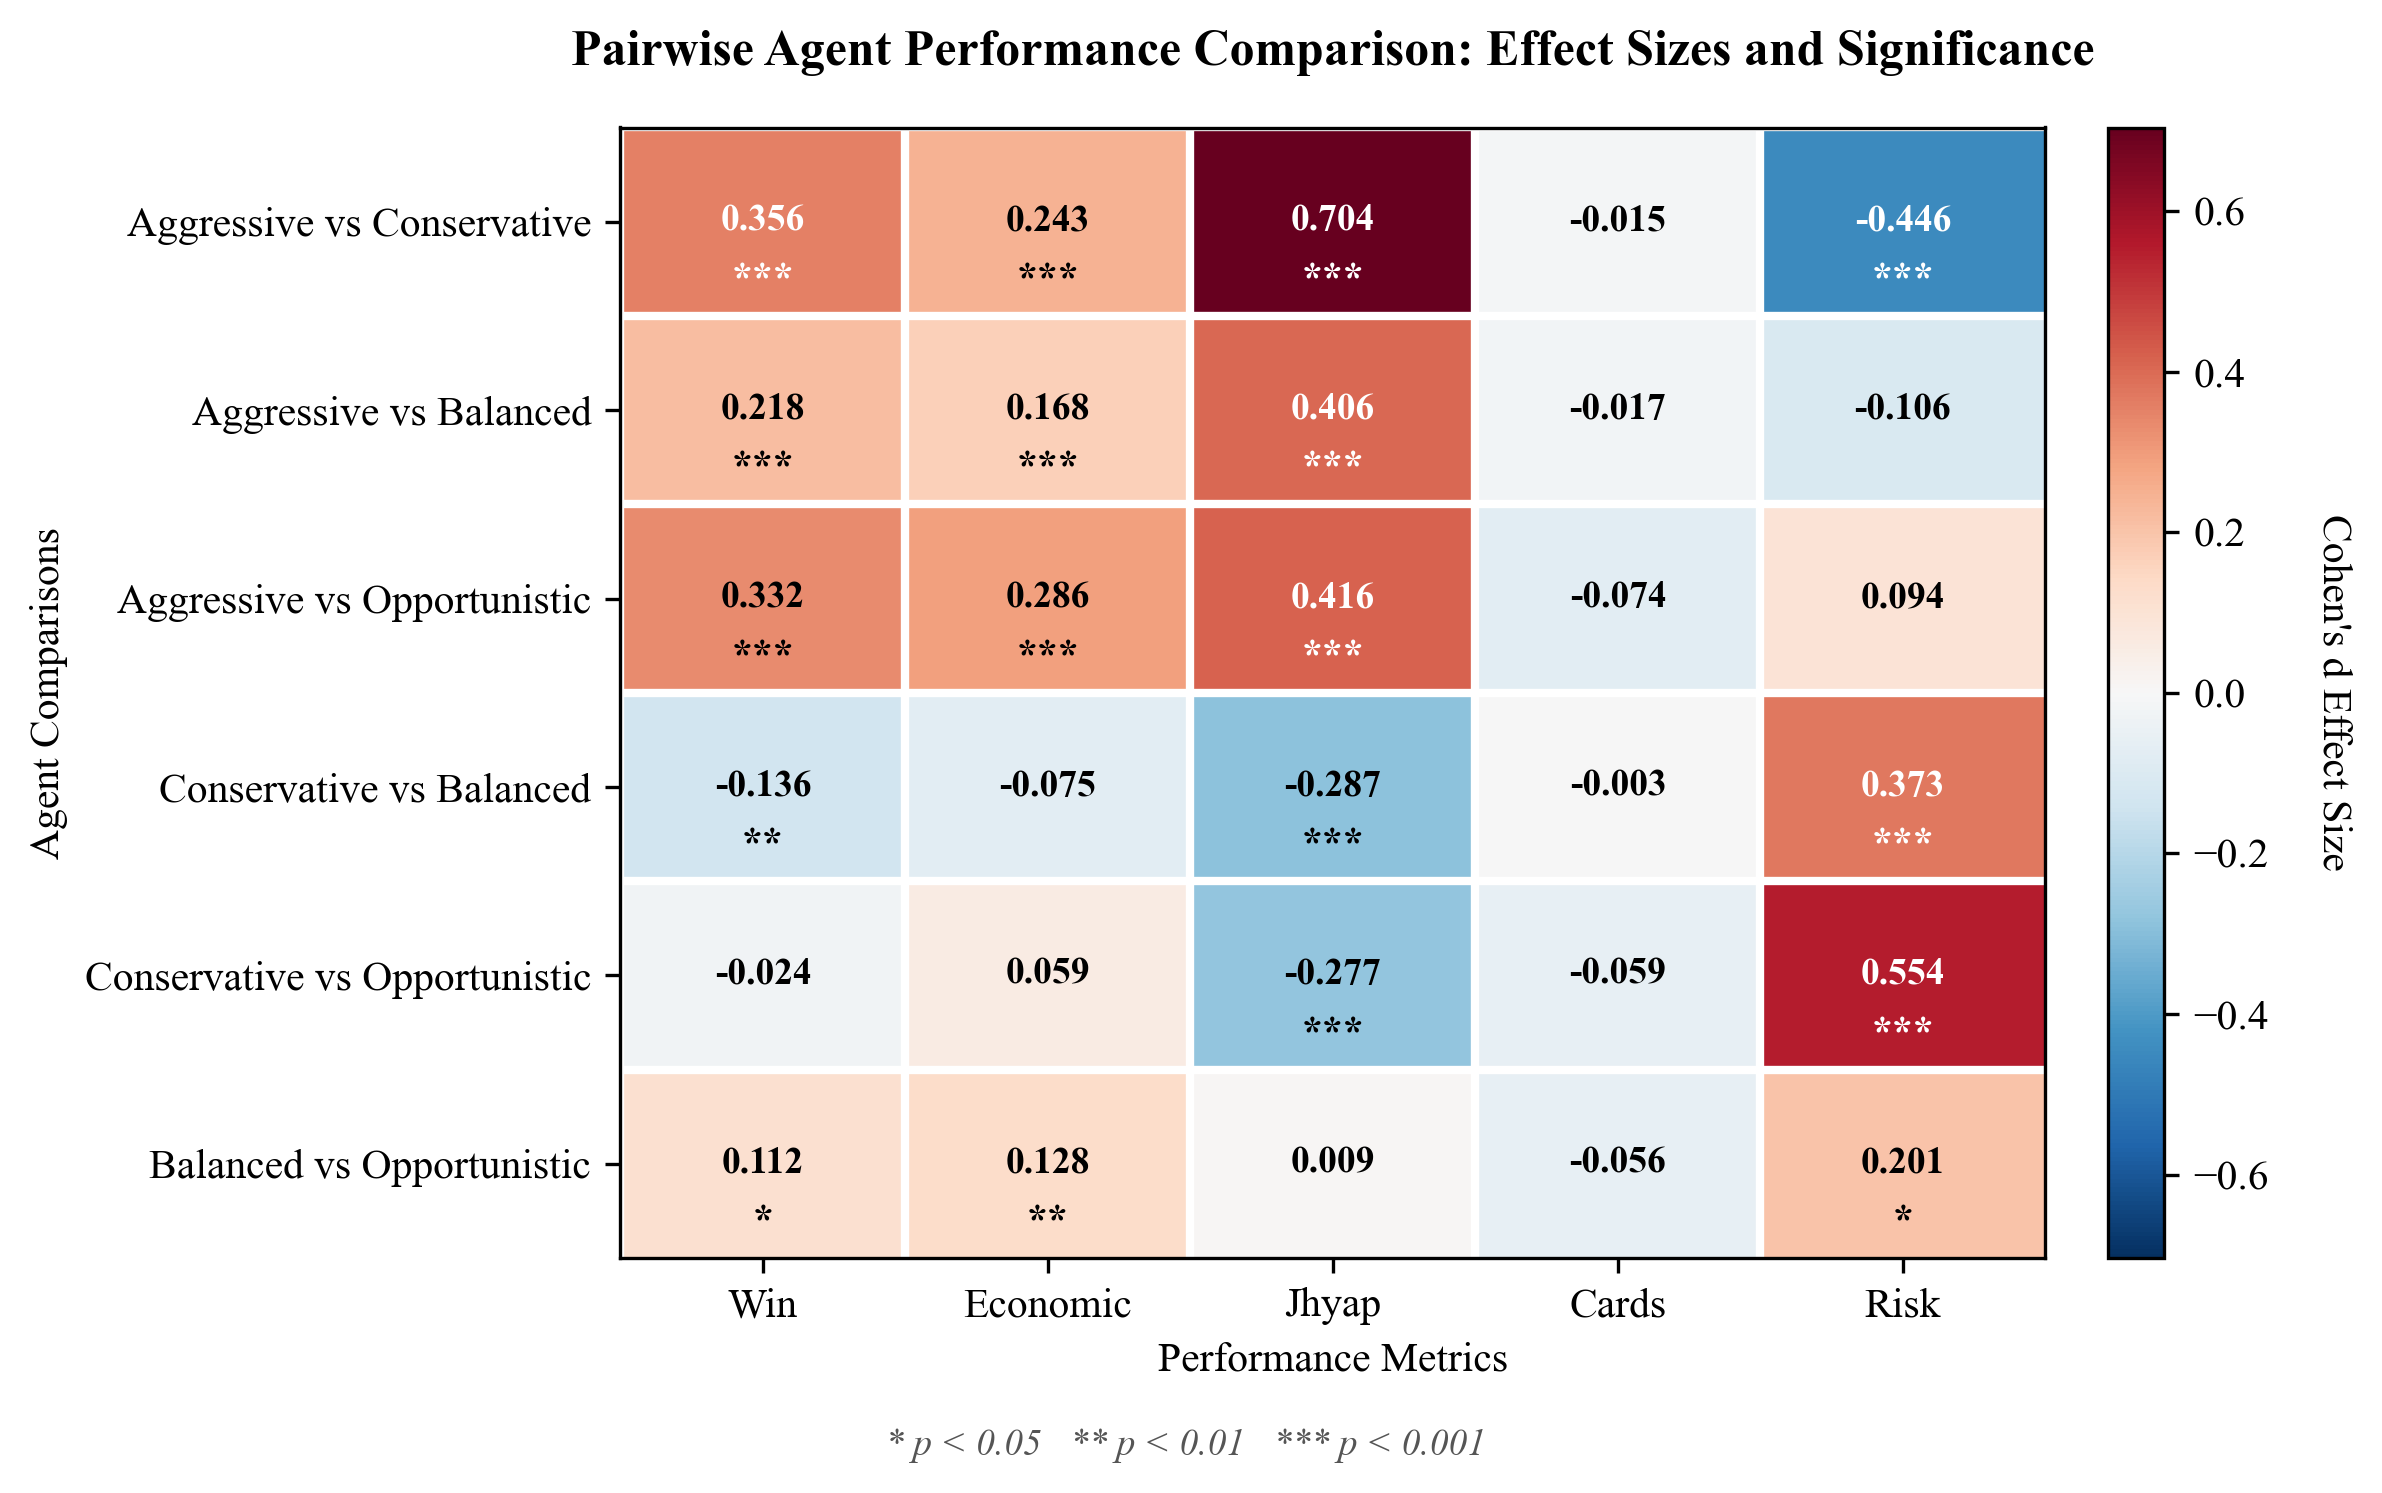

saved /Users/sahajrajmalla/Documents/dhumbal-ai/visualization/plots/player_comparison_heatmap.png


In [38]:
# Rule-based pairwise Cohen's d heatmap. Source: agents/rule_based/statistical_analysis.csv
import csv
from matplotlib.colors import TwoSlopeNorm
labelmap = {'P0': 'Aggressive', 'P1': 'Conservative', 'P2': 'Balanced', 'P3': 'Opportunistic'}
metrics = ['Win', 'Economic', 'Jhyap', 'Cards', 'Risk']
comparisons, dvals, pvals = [], [], []
with open(os.path.join(ROOT, 'agents/rule_based/statistical_analysis.csv')) as f:
    for row in csv.DictReader(f):
        a, b = row['Comparison'].split(' vs ')
        comparisons.append(f"{labelmap[a]} vs {labelmap[b]}")
        dvals.append([float(row['Win d']), float(row['Economic d']), float(row['Jhyap d']), float(row['Cards d']), float(row['Risk d'])])
        pvals.append([float(row['Win p-value']), float(row['Economic p-value']), float(row['Jhyap p-value']), float(row['Cards p-value']), float(row['Risk p-value'])])
d = np.array(dvals); p = np.array(pvals)
def mark(v):
    return '***' if v < 0.001 else '**' if v < 0.01 else '*' if v < 0.05 else ''
fig, ax = plt.subplots(figsize=(8, 5))
vmax = max(abs(d.min()), abs(d.max())); norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
im = ax.imshow(d, cmap='RdBu_r', aspect='auto', norm=norm)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cbar.set_label("Cohen's d Effect Size", rotation=270, labelpad=20)
ax.set_xticks(range(len(metrics))); ax.set_yticks(range(len(comparisons)))
ax.set_xticklabels(metrics); ax.set_yticklabels(comparisons)
ax.set_xticks(np.arange(len(metrics))-0.5, minor=True); ax.set_yticks(np.arange(len(comparisons))-0.5, minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2); ax.tick_params(which='minor', size=0)
for i in range(len(comparisons)):
    for j in range(len(metrics)):
        tc = 'white' if abs(d[i, j]) > vmax*0.5 else 'black'
        ax.text(j, i, f'{d[i, j]:.3f}', ha='center', va='center', color=tc, fontsize=9, fontweight='bold')
        mk = mark(p[i, j])
        if mk: ax.text(j, i+0.32, mk, ha='center', va='center', color=tc, fontsize=10, fontweight='bold')
ax.set_xlabel('Performance Metrics'); ax.set_ylabel('Agent Comparisons')
ax.set_title('Pairwise Agent Performance Comparison: Effect Sizes and Significance', fontweight='bold', pad=15)
fig.text(0.5, 0.02, '* p < 0.05   ** p < 0.01   *** p < 0.001', ha='center', fontsize=9, style='italic', color='#555555')
plt.tight_layout(rect=[0, 0.04, 1, 1])
out = os.path.join(PLOTS, 'player_comparison_heatmap.png')
plt.savefig(out, dpi=300, bbox_inches='tight', facecolor='white'); plt.show()
print('saved', out)


## Search-based agents: within-category tournament

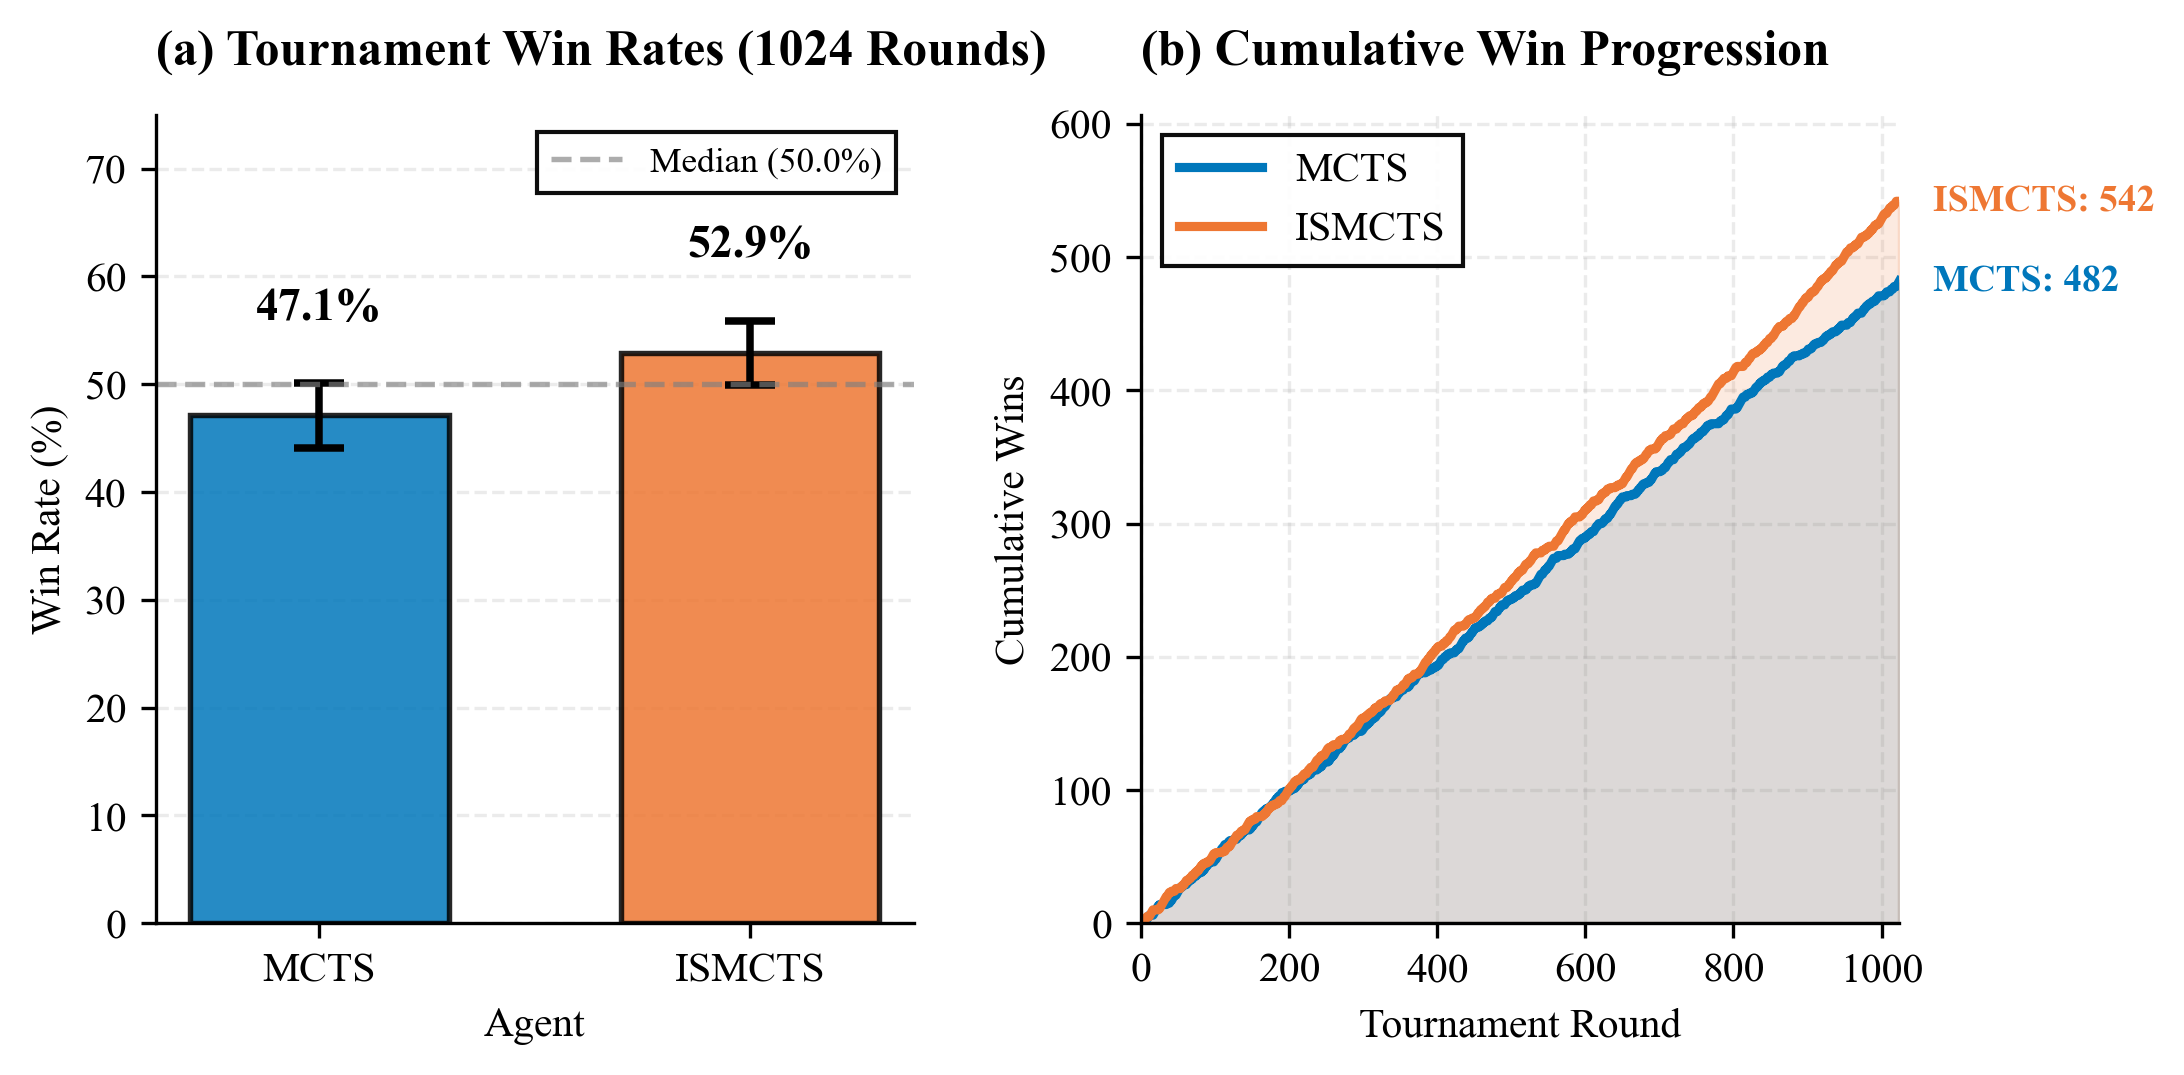

saved /Users/sahajrajmalla/Documents/dhumbal-ai/visualization/plots/search_based_tournament.png


In [39]:
# Search-based within-category tournament (2-player, 1024 rounds).
# Source: agents/search_based/game_results_rounds_1024.json
color_mcts, color_ismcts = '#0077BB', '#EE7733'
MCTS_WR, ISMCTS_WR, CI = 47.1, 52.9, 3.0
with open(os.path.join(ROOT, 'agents/search_based/game_results_rounds_1024.json')) as f:
    gj = json.load(f)
winners = [r['winner'] for r in gj['round_details']]
p0 = sum(1 for w in winners if w == 0); p1 = sum(1 for w in winners if w == 1)
ismcts_id, mcts_id = (0, 1) if p0 > p1 else (1, 0)
rounds = np.arange(1, len(winners)+1)
mcts_cum = np.cumsum([1 if w == mcts_id else 0 for w in winners])
ismcts_cum = np.cumsum([1 if w == ismcts_id else 0 for w in winners])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 3.5), gridspec_kw={'wspace': 0.30})
bars = ax1.bar(['MCTS', 'ISMCTS'], [MCTS_WR, ISMCTS_WR], yerr=[[CI, CI], [CI, CI]], capsize=6,
               color=[color_mcts, color_ismcts], edgecolor='black', linewidth=1.3, alpha=0.85,
               error_kw={'linewidth': 1.8, 'capthick': 1.8}, width=0.6)
for bar, rate in zip(bars, [MCTS_WR, ISMCTS_WR]):
    ax1.text(bar.get_x()+bar.get_width()/2., bar.get_height()+CI+5, f'{rate:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
med = np.median([MCTS_WR, ISMCTS_WR])
ax1.axhline(med, color='gray', linestyle='--', linewidth=1.3, alpha=0.65, label=f'Median ({med:.1f}%)')
ax1.set_ylabel('Win Rate (%)'); ax1.set_xlabel('Agent')
ax1.set_title('(a) Tournament Win Rates (1024 Rounds)', loc='left', fontweight='bold', pad=12)
ax1.set_ylim(0, 75); ax1.grid(True, axis='y', linestyle='--', alpha=0.25); ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
ax1.legend(loc='upper right', framealpha=0.95, edgecolor='black', frameon=True, fancybox=False, fontsize=8.5)
ax2.plot(rounds, mcts_cum, color=color_mcts, linewidth=2.2, label='MCTS')
ax2.plot(rounds, ismcts_cum, color=color_ismcts, linewidth=2.2, label='ISMCTS')
ax2.fill_between(rounds, mcts_cum, alpha=0.15, color=color_mcts)
ax2.fill_between(rounds, ismcts_cum, alpha=0.15, color=color_ismcts)
ax2.annotate(f'MCTS: {mcts_cum[-1]:.0f}', xy=(rounds[-1], mcts_cum[-1]), xytext=(8, 0), textcoords='offset points', fontsize=9, fontweight='bold', color=color_mcts, va='center')
ax2.annotate(f'ISMCTS: {ismcts_cum[-1]:.0f}', xy=(rounds[-1], ismcts_cum[-1]), xytext=(8, 0), textcoords='offset points', fontsize=9, fontweight='bold', color=color_ismcts, va='center')
ax2.set_xlabel('Tournament Round'); ax2.set_ylabel('Cumulative Wins')
ax2.set_title('(b) Cumulative Win Progression', loc='left', fontweight='bold', pad=12)
ax2.legend(loc='upper left', framealpha=0.95, edgecolor='black', frameon=True, fancybox=False)
ax2.grid(True, linestyle='--', alpha=0.25); ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
ax2.set_xlim(0, rounds[-1]); ax2.set_ylim(0, max(mcts_cum[-1], ismcts_cum[-1])*1.12)
out = os.path.join(PLOTS, 'search_based_tournament.png')
plt.savefig(out, dpi=300, bbox_inches='tight', facecolor='white'); plt.show()
print('saved', out)


## Learning agents: training dynamics

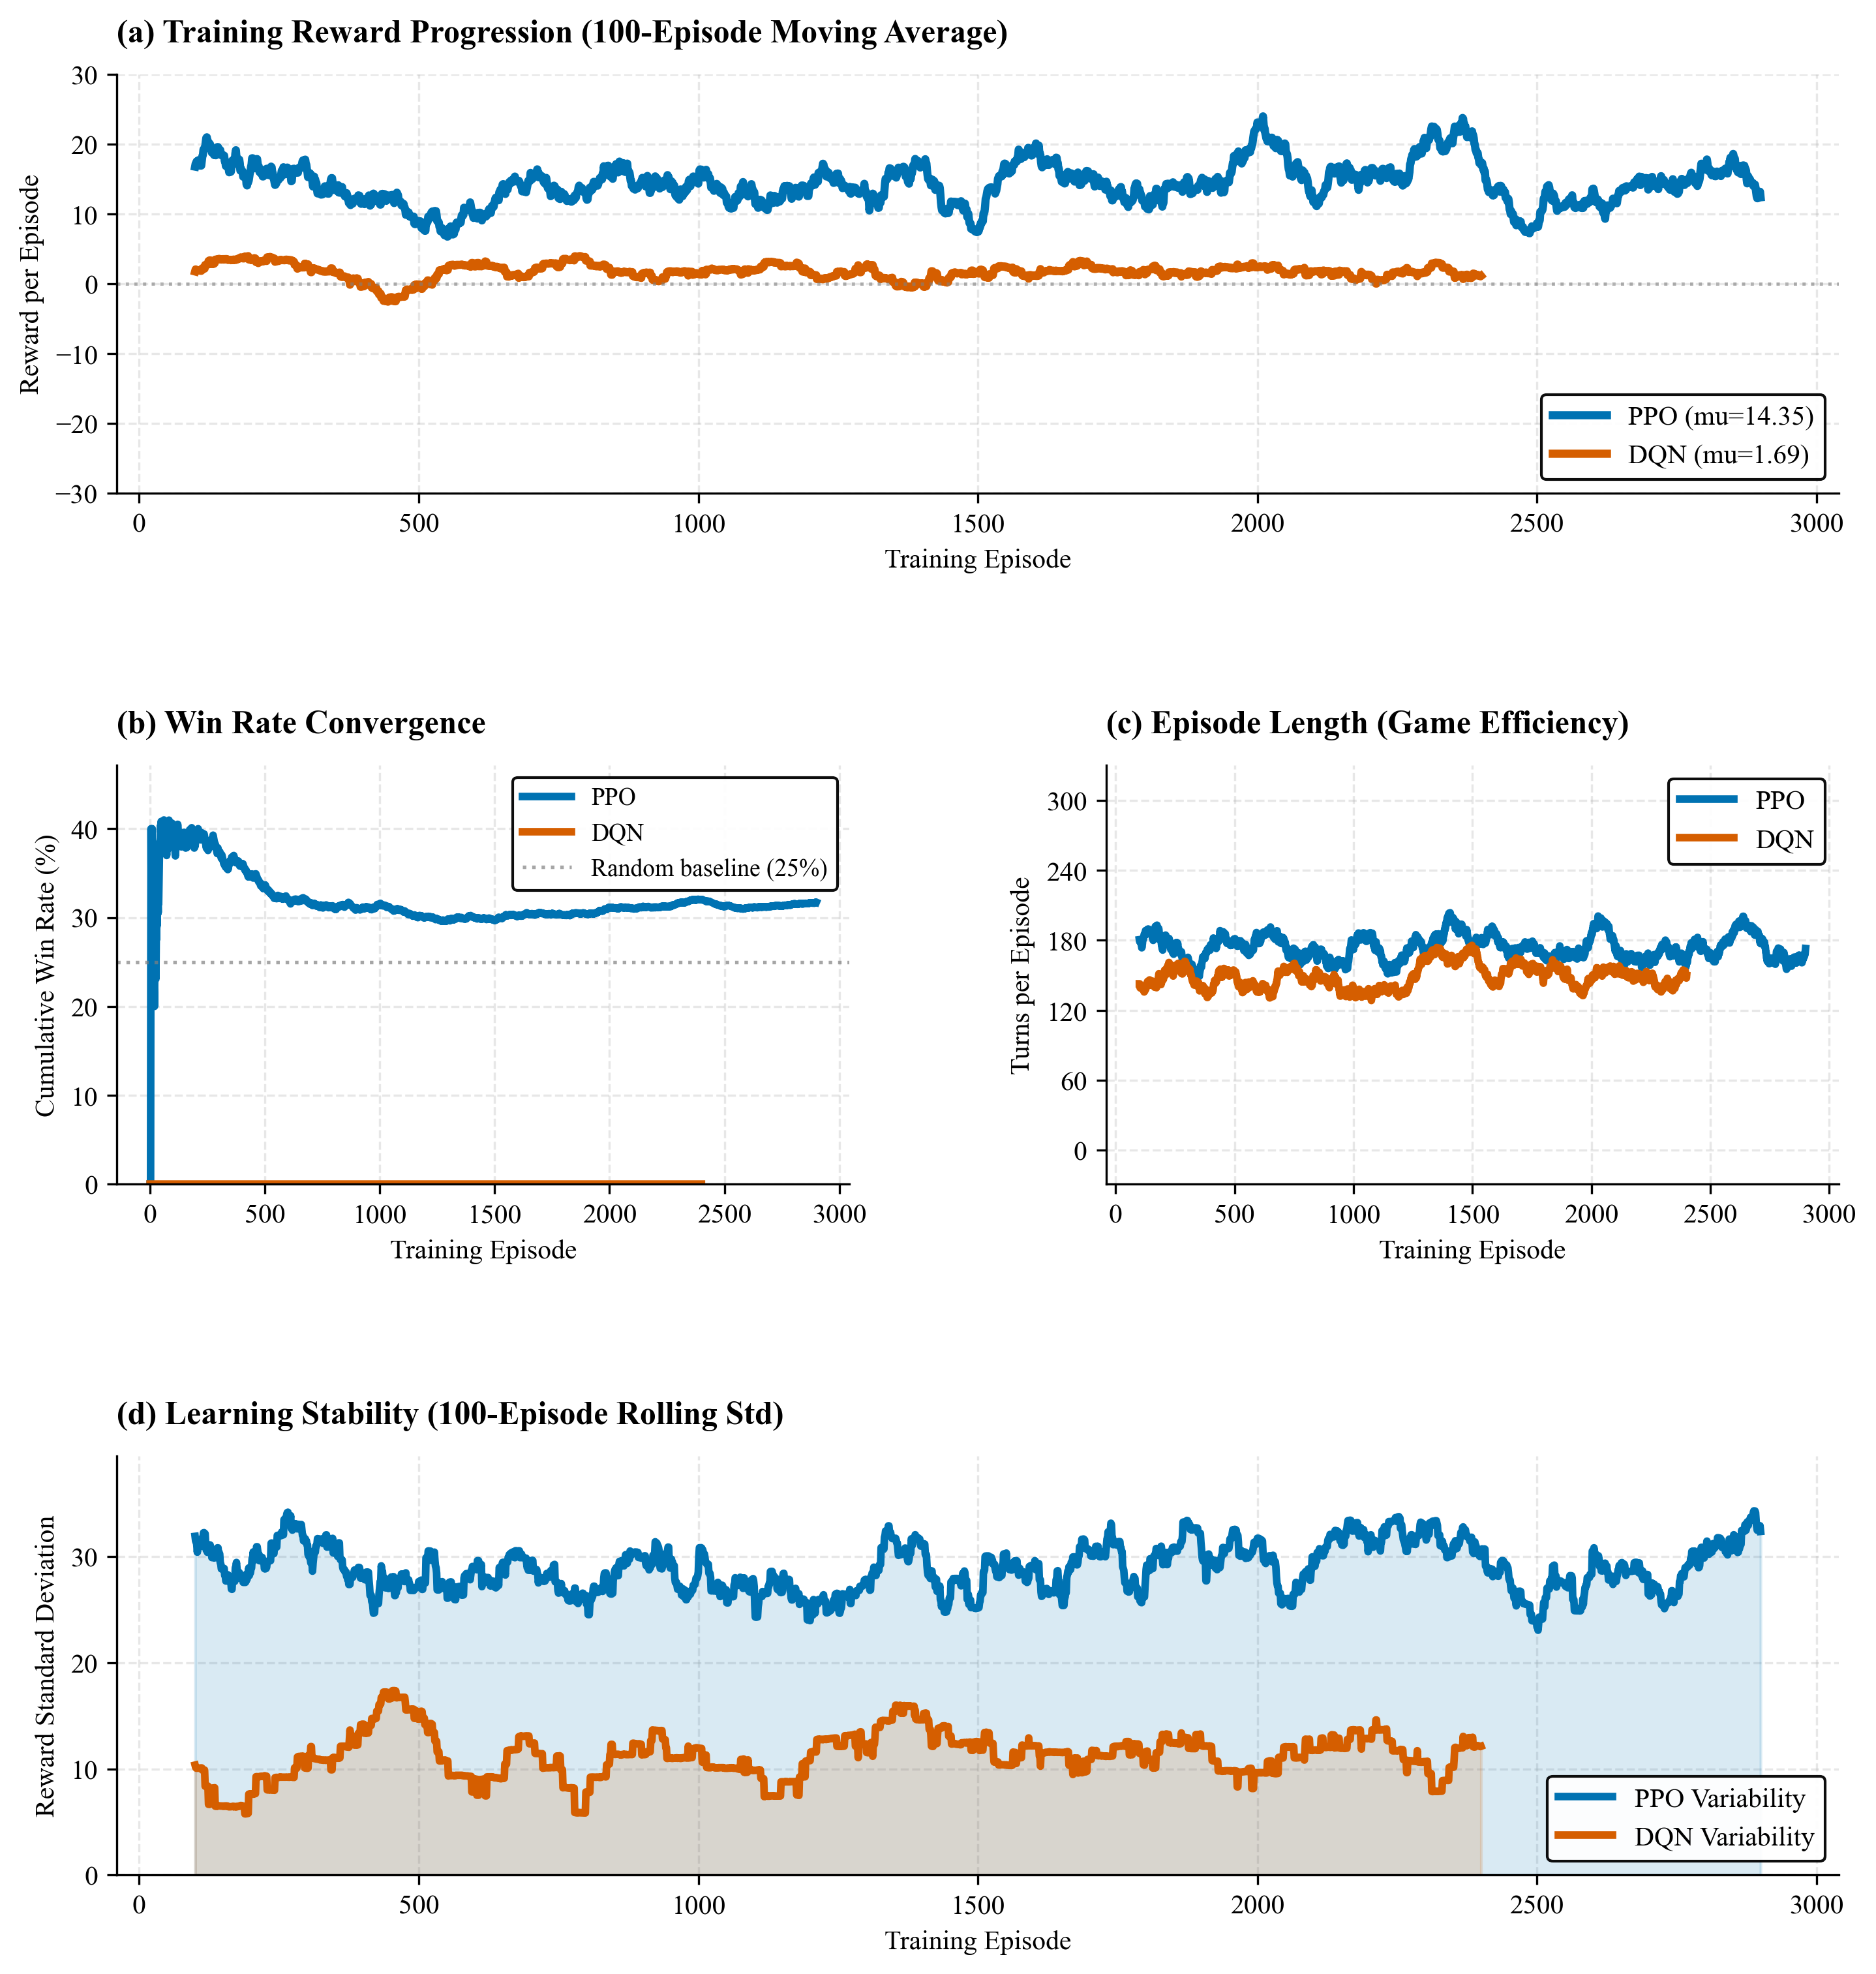

saved /Users/sahajrajmalla/Documents/dhumbal-ai/visualization/plots/figure1_training_dynamics_final.png | PPO final cum wr=31.72 DQN=0.00


In [40]:
# Learning-agent training dynamics (4-player self-play vs rule-based mix).
# Source: agents/learning_based/{ppo,dqn}/*_training_results.csv
import pandas as pd
from matplotlib.ticker import MaxNLocator, MultipleLocator
color_ppo, color_dqn = '#0072B2', '#D55E00'
ppo = pd.read_csv(os.path.join(ROOT, 'agents/learning_based/ppo/ppo_training_results.csv'))
dqn = pd.read_csv(os.path.join(ROOT, 'agents/learning_based/dqn/dqn_training_results.csv'))
RAND = 25.0  # 4-player random-baseline win rate
fig = plt.figure(figsize=(10.0, 10.0))
gs = fig.add_gridspec(3, 2, hspace=0.65, wspace=0.35, left=0.08, right=0.96, top=0.97, bottom=0.05)
pe, de = ppo['Episode'].values, dqn['Episode'].values
pr, dr = ppo['Reward'].values, dqn['Reward'].values
pw, dw = ppo['Win'].values, dqn['Win'].values
pt, dt = ppo['Turns'].values, dqn['Turns'].values
W = 100
ax1 = fig.add_subplot(gs[0, :])
ps = np.convolve(pr, np.ones(W)/W, 'valid'); ds = np.convolve(dr, np.ones(W)/W, 'valid')
ax1.plot(pe[W-1:], np.clip(ps, -30, 30), color=color_ppo, linewidth=3.0, label=f'PPO (mu={np.mean(pr):.2f})')
ax1.plot(de[W-1:], np.clip(ds, -30, 30), color=color_dqn, linewidth=3.0, label=f'DQN (mu={np.mean(dr):.2f})')
ax1.axhline(0, color='gray', linestyle=':', linewidth=1.2, alpha=0.6)
ax1.set_ylim(-30, 30); ax1.yaxis.set_major_locator(MultipleLocator(10))
ax1.set_xlabel('Training Episode'); ax1.set_ylabel('Reward per Episode')
ax1.set_title('(a) Training Reward Progression (100-Episode Moving Average)', loc='left', fontweight='bold', pad=12)
ax1.legend(loc='lower right', framealpha=0.95, edgecolor='black'); ax1.grid(True, linestyle='--', alpha=0.3); ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
ax2 = fig.add_subplot(gs[1, 0])
pcw = np.cumsum(pw)/np.arange(1, len(pw)+1)*100
dcw = np.cumsum(dw)/np.arange(1, len(dw)+1)*100
ax2.plot(pe, pcw, color=color_ppo, linewidth=2.8, label='PPO')
ax2.plot(de, dcw, color=color_dqn, linewidth=2.8, label='DQN')
ax2.axhline(RAND, color='gray', linestyle=':', linewidth=1.3, alpha=0.7, label=f'Random baseline ({RAND:.0f}%)')
ax2.set_ylim(0, max(40, np.nanmax(pcw)*1.15)); ax2.yaxis.set_major_locator(MultipleLocator(10))
ax2.set_xlabel('Training Episode'); ax2.set_ylabel('Cumulative Win Rate (%)')
ax2.set_title('(b) Win Rate Convergence', loc='left', fontweight='bold', pad=12)
ax2.legend(loc='best', framealpha=0.95, edgecolor='black', fontsize=9); ax2.grid(True, linestyle='--', alpha=0.3); ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
ax3 = fig.add_subplot(gs[1, 1])
pts = np.convolve(pt, np.ones(W)/W, 'valid'); dts = np.convolve(dt, np.ones(W)/W, 'valid')
ax3.plot(pe[W-1:], pts, color=color_ppo, linewidth=2.8, label='PPO')
ax3.plot(de[W-1:], dts, color=color_dqn, linewidth=2.8, label='DQN')
allt = np.concatenate([pt, dt]); pad = (allt.max()-allt.min())*0.1
ax3.set_ylim(allt.min()-pad, allt.max()+pad); ax3.yaxis.set_major_locator(MaxNLocator(6, integer=True))
ax3.set_xlabel('Training Episode'); ax3.set_ylabel('Turns per Episode')
ax3.set_title('(c) Episode Length (Game Efficiency)', loc='left', fontweight='bold', pad=12)
ax3.legend(loc='best', framealpha=0.95, edgecolor='black'); ax3.grid(True, linestyle='--', alpha=0.3); ax3.set_axisbelow(True)
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)
ax4 = fig.add_subplot(gs[2, :])
prs = pd.Series(pr).rolling(100).std(); drs = pd.Series(dr).rolling(100).std()
ax4.plot(pe, prs, color=color_ppo, linewidth=2.8, label='PPO Variability')
ax4.plot(de, drs, color=color_dqn, linewidth=2.8, label='DQN Variability')
ax4.fill_between(pe, 0, prs, color=color_ppo, alpha=0.15); ax4.fill_between(de, 0, drs, color=color_dqn, alpha=0.15)
allstd = np.concatenate([prs.dropna(), drs.dropna()])
if len(allstd): ax4.set_ylim(0, allstd.max()*1.15)
ax4.set_xlabel('Training Episode'); ax4.set_ylabel('Reward Standard Deviation')
ax4.set_title('(d) Learning Stability (100-Episode Rolling Std)', loc='left', fontweight='bold', pad=12)
ax4.legend(loc='lower right', framealpha=0.95, edgecolor='black'); ax4.grid(True, linestyle='--', alpha=0.3); ax4.set_axisbelow(True)
ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)
plt.tight_layout(pad=2.0, h_pad=3.0, w_pad=2.0)
out = os.path.join(PLOTS, 'figure1_training_dynamics_final.png')
plt.savefig(out, dpi=300, bbox_inches='tight', facecolor='white'); plt.show()
print('saved', out, '| PPO final cum wr=%.2f DQN=%.2f' % (pcw[-1], dcw[-1]))


## Learning agents: selection tournament (two PPO vs two DQN)

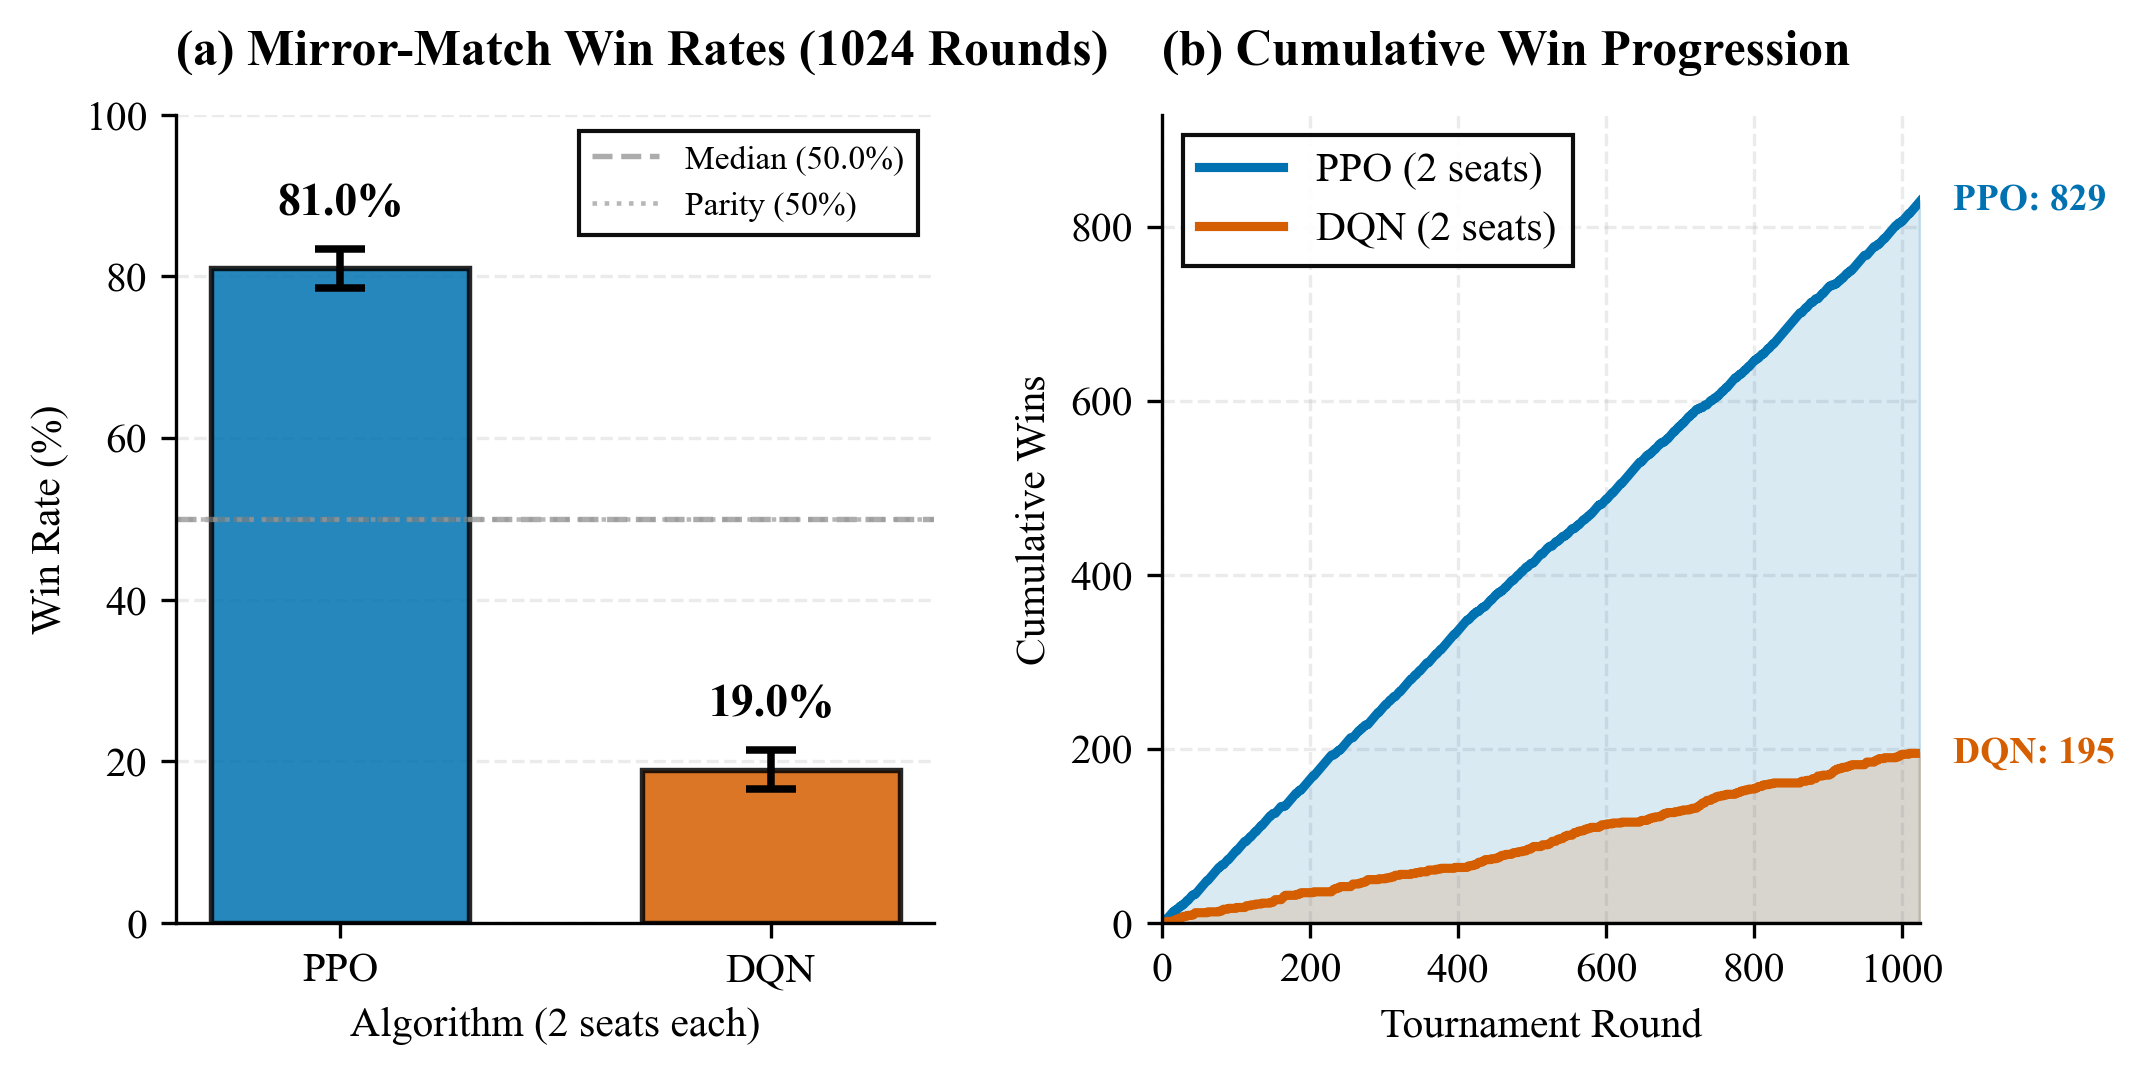

saved /Users/sahajrajmalla/Documents/dhumbal-ai/visualization/plots/figure2_tournament_performance.png | PPO 81.0 DQN 19.0


In [41]:
# Learning-based selection: 2xPPO vs 2xDQN, 4-player mirror, 1024 rounds.
# Sources: learning_selection_metrics_*.csv and learning_selection_results_*.json
import pandas as pd
color_ppo, color_dqn = '#0072B2', '#D55E00'
mcsv = sorted(glob.glob(os.path.join(ROOT, 'agents/learning_based/learning_selection_metrics_*.csv')))[-1]
mjson = sorted(glob.glob(os.path.join(ROOT, 'agents/learning_based/learning_selection_results_*.json')))[-1]
m = pd.read_csv(mcsv)
ppo_row = m[m['Algorithm'].str.contains('PPO', case=False)].iloc[0]
dqn_row = m[m['Algorithm'].str.contains('DQN', case=False)].iloc[0]
ppo_wr, dqn_wr = float(ppo_row['Win Rate (%)']), float(dqn_row['Win Rate (%)'])
ppo_ci, dqn_ci = float(ppo_row['Win CI (%)']), float(dqn_row['Win CI (%)'])
with open(mjson) as f:
    j = json.load(f)
winners = [r['winner'] for r in j['round_details']]
rounds = np.arange(1, len(winners)+1)
ppo_seats = set(j['algorithm_performance']['PPO']['seats'])
ppo_cum = np.cumsum([1 if w in ppo_seats else 0 for w in winners])
dqn_cum = np.cumsum([1 if (w >= 0 and w not in ppo_seats) else 0 for w in winners])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 3.5), gridspec_kw={'wspace': 0.30})
bars = ax1.bar(['PPO', 'DQN'], [ppo_wr, dqn_wr], yerr=[[ppo_ci, dqn_ci], [ppo_ci, dqn_ci]], capsize=6,
               color=[color_ppo, color_dqn], edgecolor='black', linewidth=1.3, alpha=0.85,
               error_kw={'linewidth': 1.8, 'capthick': 1.8}, width=0.6)
for bar, rate, ci in zip(bars, [ppo_wr, dqn_wr], [ppo_ci, dqn_ci]):
    ax1.text(bar.get_x()+bar.get_width()/2., bar.get_height()+ci+3, f'{rate:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
med = np.median([ppo_wr, dqn_wr])
ax1.axhline(med, color='gray', linestyle='--', linewidth=1.3, alpha=0.65, label=f'Median ({med:.1f}%)')
ax1.axhline(50, color='#999999', linestyle=':', linewidth=1.1, alpha=0.7, label='Parity (50%)')
ax1.set_ylabel('Win Rate (%)'); ax1.set_xlabel('Algorithm (2 seats each)')
ax1.set_title('(a) Mirror-Match Win Rates (1024 Rounds)', loc='left', fontweight='bold', pad=12)
ax1.set_ylim(0, 100); ax1.grid(True, axis='y', linestyle='--', alpha=0.25); ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
ax1.legend(loc='upper right', framealpha=0.95, edgecolor='black', frameon=True, fancybox=False, fontsize=8)
ax2.plot(rounds, ppo_cum, color=color_ppo, linewidth=2.2, label='PPO (2 seats)')
ax2.plot(rounds, dqn_cum, color=color_dqn, linewidth=2.2, label='DQN (2 seats)')
ax2.fill_between(rounds, ppo_cum, alpha=0.15, color=color_ppo)
ax2.fill_between(rounds, dqn_cum, alpha=0.15, color=color_dqn)
ax2.annotate(f'PPO: {ppo_cum[-1]:.0f}', xy=(rounds[-1], ppo_cum[-1]), xytext=(8, 0), textcoords='offset points', fontsize=9, fontweight='bold', color=color_ppo, va='center')
ax2.annotate(f'DQN: {dqn_cum[-1]:.0f}', xy=(rounds[-1], dqn_cum[-1]), xytext=(8, 0), textcoords='offset points', fontsize=9, fontweight='bold', color=color_dqn, va='center')
ax2.set_xlabel('Tournament Round'); ax2.set_ylabel('Cumulative Wins')
ax2.set_title('(b) Cumulative Win Progression', loc='left', fontweight='bold', pad=12)
ax2.legend(loc='upper left', framealpha=0.95, edgecolor='black', frameon=True, fancybox=False)
ax2.grid(True, linestyle='--', alpha=0.25); ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
ax2.set_xlim(0, rounds[-1]); ax2.set_ylim(0, max(ppo_cum[-1], dqn_cum[-1])*1.12)
out = os.path.join(PLOTS, 'figure2_tournament_performance.png')
plt.savefig(out, dpi=300, bbox_inches='tight', facecolor='white'); plt.show()
print('saved', out, '| PPO %.1f DQN %.1f' % (ppo_wr, dqn_wr))


## Learning agents: cross-regime generalization gap

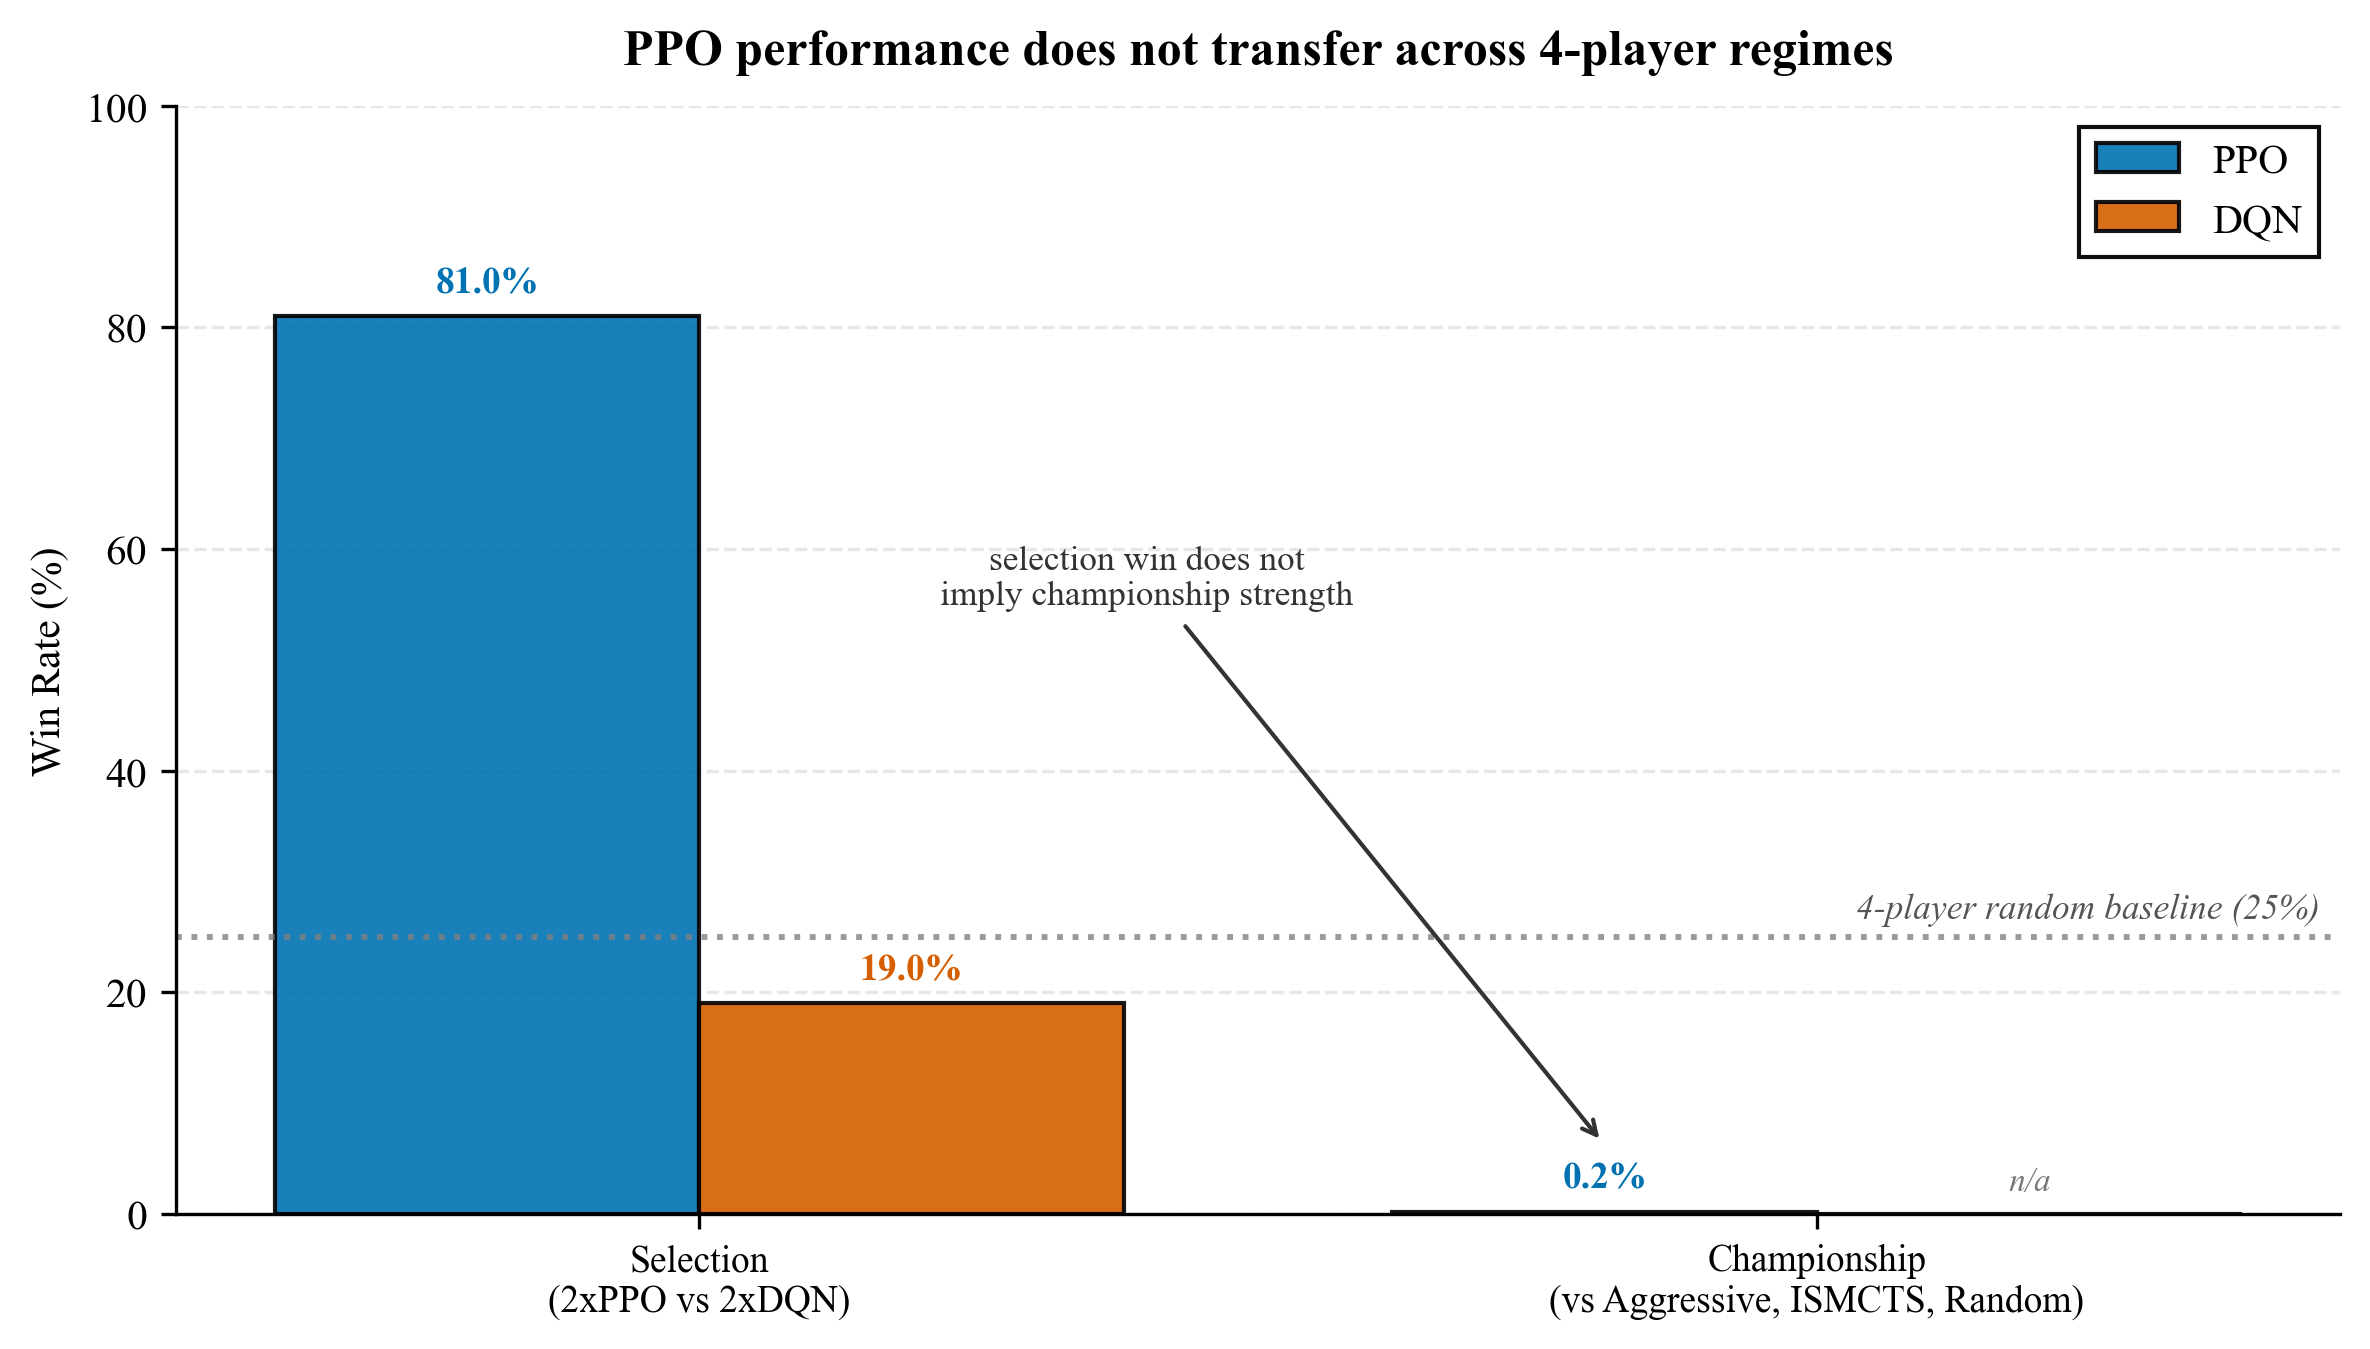

saved /Users/sahajrajmalla/Documents/dhumbal-ai/visualization/plots/rl_generalization_gap.png


In [42]:
# RL generalization gap: PPO win rate across the selection and championship regimes,
# showing that winning the isolated selection bracket does NOT imply strength in the
# mixed championship field. Sources: selection / championship summaries.
import pandas as pd
color_ppo, color_dqn = '#0072B2', '#D55E00'
mcsv = sorted(glob.glob(os.path.join(ROOT, 'agents/learning_based/learning_selection_metrics_*.csv')))[-1]
m = pd.read_csv(mcsv)
sel_ppo = float(m[m['Algorithm'].str.contains('PPO', case=False)].iloc[0]['Win Rate (%)'])
sel_dqn = float(m[m['Algorithm'].str.contains('DQN', case=False)].iloc[0]['Win Rate (%)'])
champ = json.load(open(os.path.join(ROOT, 'championship/final_results.json')))
champ_ppo = champ['player_performance']['win_rates']['PPO']
stages = ['Selection\n(2xPPO vs 2xDQN)', 'Championship\n(vs Aggressive, ISMCTS, Random)']
ppo_vals = [sel_ppo, champ_ppo]
dqn_vals = [sel_dqn, np.nan]
fig, ax = plt.subplots(figsize=(8.0, 4.6))
x = np.arange(len(stages)); w = 0.38
b1 = ax.bar(x-w/2, ppo_vals, w, color=color_ppo, edgecolor='black', linewidth=1.0, alpha=0.9, label='PPO')
dvals_plot = [v if not np.isnan(v) else 0 for v in dqn_vals]
b2 = ax.bar(x+w/2, dvals_plot, w, color=color_dqn, edgecolor='black', linewidth=1.0, alpha=0.9, label='DQN')
ax.axhline(25, color='gray', linestyle=':', linewidth=1.4, alpha=0.8)
ax.text(1.45, 26, '4-player random baseline (25%)', ha='right', va='bottom', fontsize=8.5, style='italic', color='#555555')
for bar, v in zip(b1, ppo_vals):
    ax.text(bar.get_x()+bar.get_width()/2., v+1.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color=color_ppo)
for bar, v in zip(b2, dqn_vals):
    if np.isnan(v):
        ax.text(bar.get_x()+bar.get_width()/2., 1.5, 'n/a', ha='center', va='bottom', fontsize=8, style='italic', color='#777777')
    else:
        ax.text(bar.get_x()+bar.get_width()/2., v+1.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color=color_dqn)
ax.set_xticks(x); ax.set_xticklabels(stages, fontsize=9)
ax.set_ylabel('Win Rate (%)'); ax.set_ylim(0, 100)
ax.set_title('PPO performance does not transfer across 4-player regimes', fontweight='bold', pad=10)
ax.grid(True, axis='y', linestyle='--', alpha=0.3); ax.set_axisbelow(True)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', framealpha=0.95, edgecolor='black', frameon=True, fancybox=False)
ax.annotate('selection win does not\nimply championship strength',
            xy=(1-w/2, champ_ppo + 6), xytext=(0.40, 55), fontsize=8.5, color='#333333',
            ha='center', arrowprops=dict(arrowstyle='->', color='#333333', lw=1.0))
plt.tight_layout()
out = os.path.join(PLOTS, 'rl_generalization_gap.png')
plt.savefig(out, dpi=300, bbox_inches='tight', facecolor='white'); plt.show()
print('saved', out)

## Cross-category championship: performance

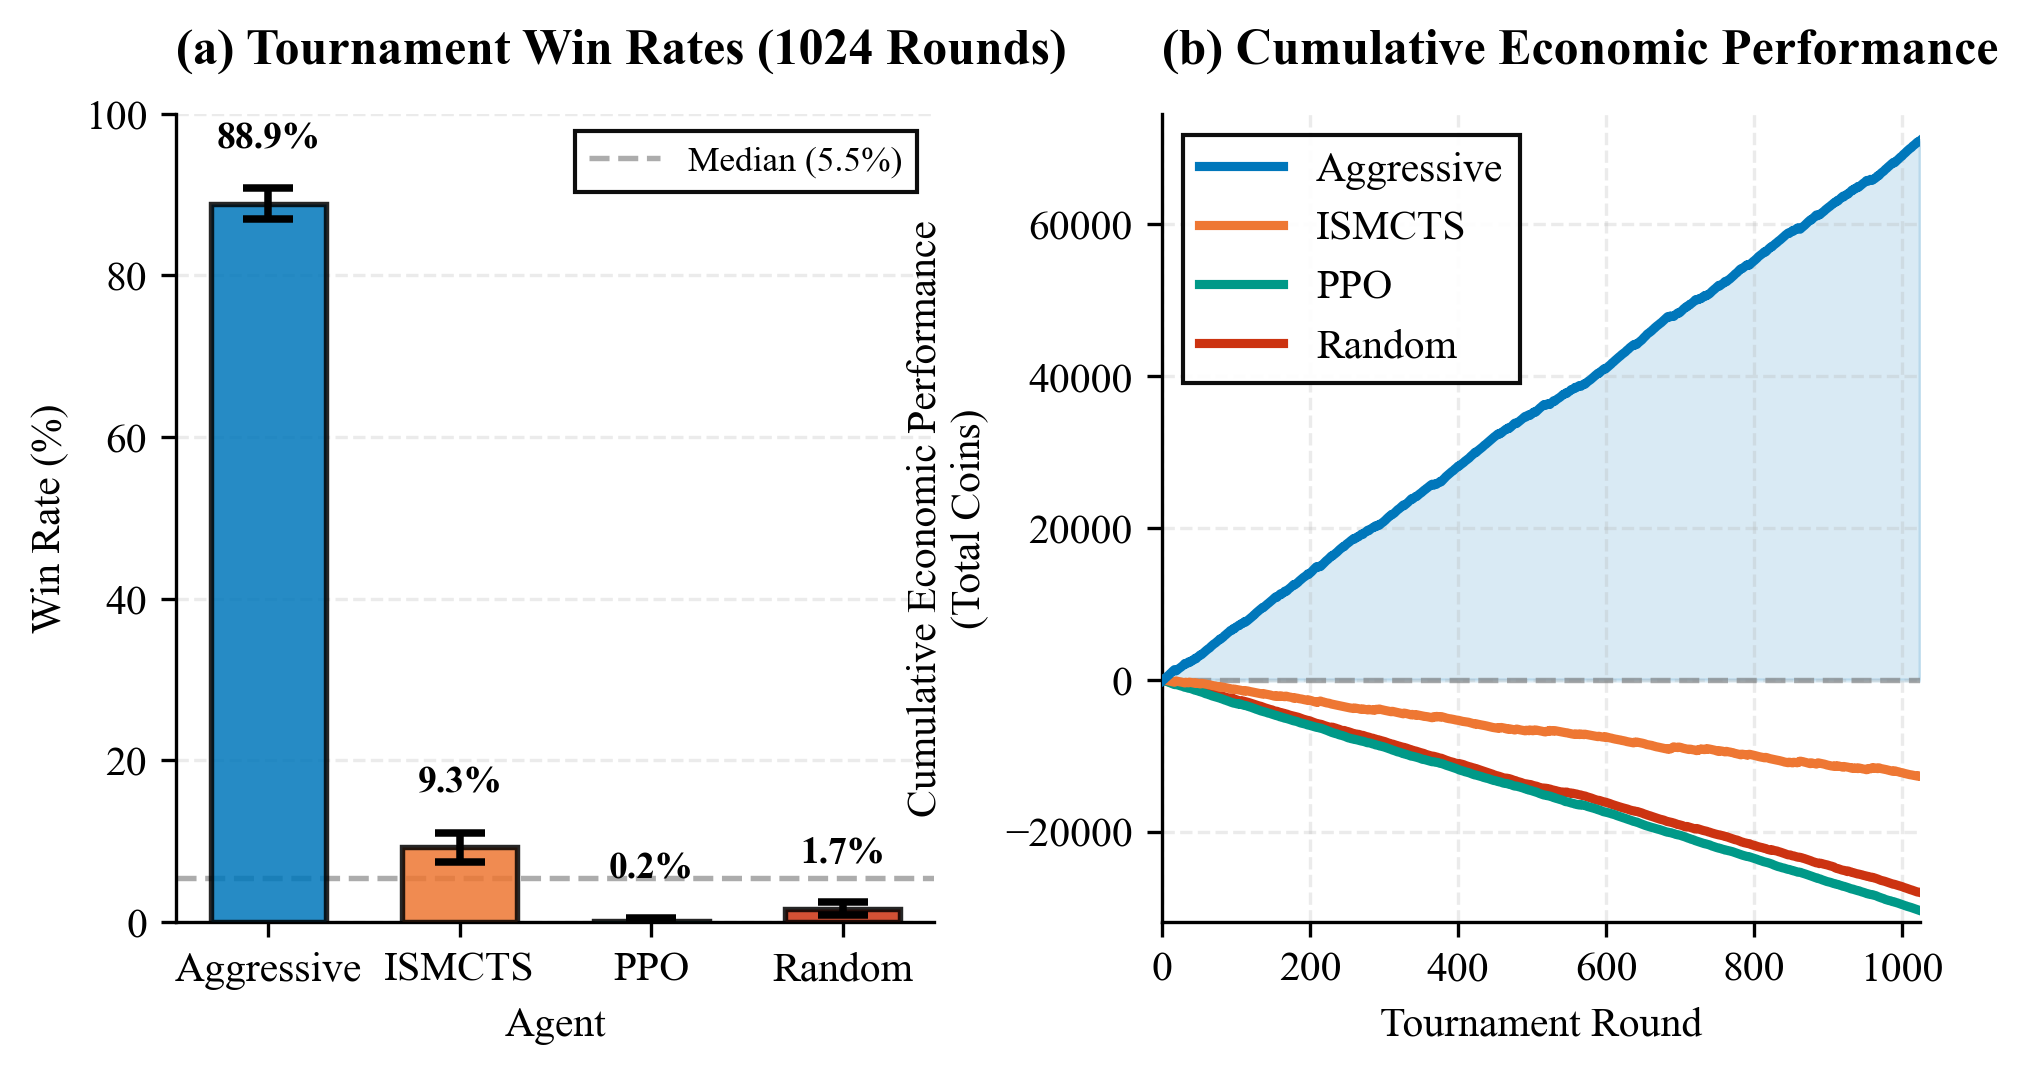

saved /Users/sahajrajmalla/Documents/dhumbal-ai/visualization/plots/championship_plots.png


In [43]:
# Cross-category championship (4-player, 1024 rounds).
# Source: championship/final_results.json
cmap = {'Aggressive': '#0077BB', 'ISMCTS': '#EE7733', 'PPO': '#009988', 'Random': '#CC3311'}
with open(os.path.join(ROOT, 'championship/final_results.json')) as f:
    data = json.load(f)
pp = data['player_performance']
names = data['game_summary']['player_names']
order = ['Aggressive', 'ISMCTS', 'PPO', 'Random']
win = [pp['win_rates'][a] for a in order]
ci = [pp['win_ci'][a] for a in order]
colors = [cmap[a] for a in order]
rd = data['round_details']
run = {n: 0.0 for n in names}; cum = {n: [] for n in names}
for r in rd:
    for i, n in enumerate(names):
        run[n] += r['coin_changes'][i]; cum[n].append(run[n])
rounds = np.arange(1, len(rd)+1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 3.5), gridspec_kw={'wspace': 0.30})
x = np.arange(len(order))
bars = ax1.bar(x, win, yerr=[ci, ci], capsize=6, color=colors, edgecolor='black', linewidth=1.3,
               alpha=0.85, width=0.6, error_kw={'linewidth': 1.8, 'capthick': 1.8}, zorder=3)
for bar, rate, c in zip(bars, win, ci):
    ax1.text(bar.get_x()+bar.get_width()/2., bar.get_height()+c+4, f'{rate:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
med = np.median(win)
ax1.axhline(med, color='gray', linestyle='--', linewidth=1.3, alpha=0.65, label=f'Median ({med:.1f}%)')
ax1.set_ylabel('Win Rate (%)'); ax1.set_xlabel('Agent')
ax1.set_title('(a) Tournament Win Rates (1024 Rounds)', loc='left', fontweight='bold', pad=12)
ax1.set_xticks(x); ax1.set_xticklabels(order); ax1.set_ylim(0, 100)
ax1.grid(True, axis='y', linestyle='--', alpha=0.25); ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
ax1.legend(loc='upper right', framealpha=0.95, edgecolor='black', frameon=True, fancybox=False, fontsize=8.5)
for a, z in zip(order, [4, 3, 2, 1]):
    ax2.plot(rounds, cum[a], color=cmap[a], linewidth=2.2, label=a, zorder=z)
ax2.fill_between(rounds, 0, cum['Aggressive'], color=cmap['Aggressive'], alpha=0.15, zorder=0)
ax2.axhline(0, color='gray', linestyle='--', linewidth=1.3, alpha=0.65)
ax2.set_xlabel('Tournament Round'); ax2.set_ylabel('Cumulative Economic Performance\n(Total Coins)')
ax2.set_title('(b) Cumulative Economic Performance', loc='left', fontweight='bold', pad=12)
ax2.legend(loc='upper left', frameon=True, fancybox=False, framealpha=0.95, edgecolor='black')
ax2.grid(True, linestyle='--', alpha=0.25); ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
ax2.set_xlim(0, len(rd))
allv = np.concatenate([np.array(cum[a]) for a in order])
ax2.set_ylim(min(0, allv.min())*1.05, allv.max()*1.05)
out = os.path.join(PLOTS, 'championship_plots.png')
plt.savefig(out, dpi=300, bbox_inches='tight', facecolor='white'); plt.show()
print('saved', out)


## Cross-category championship: pairwise effect-size heatmap

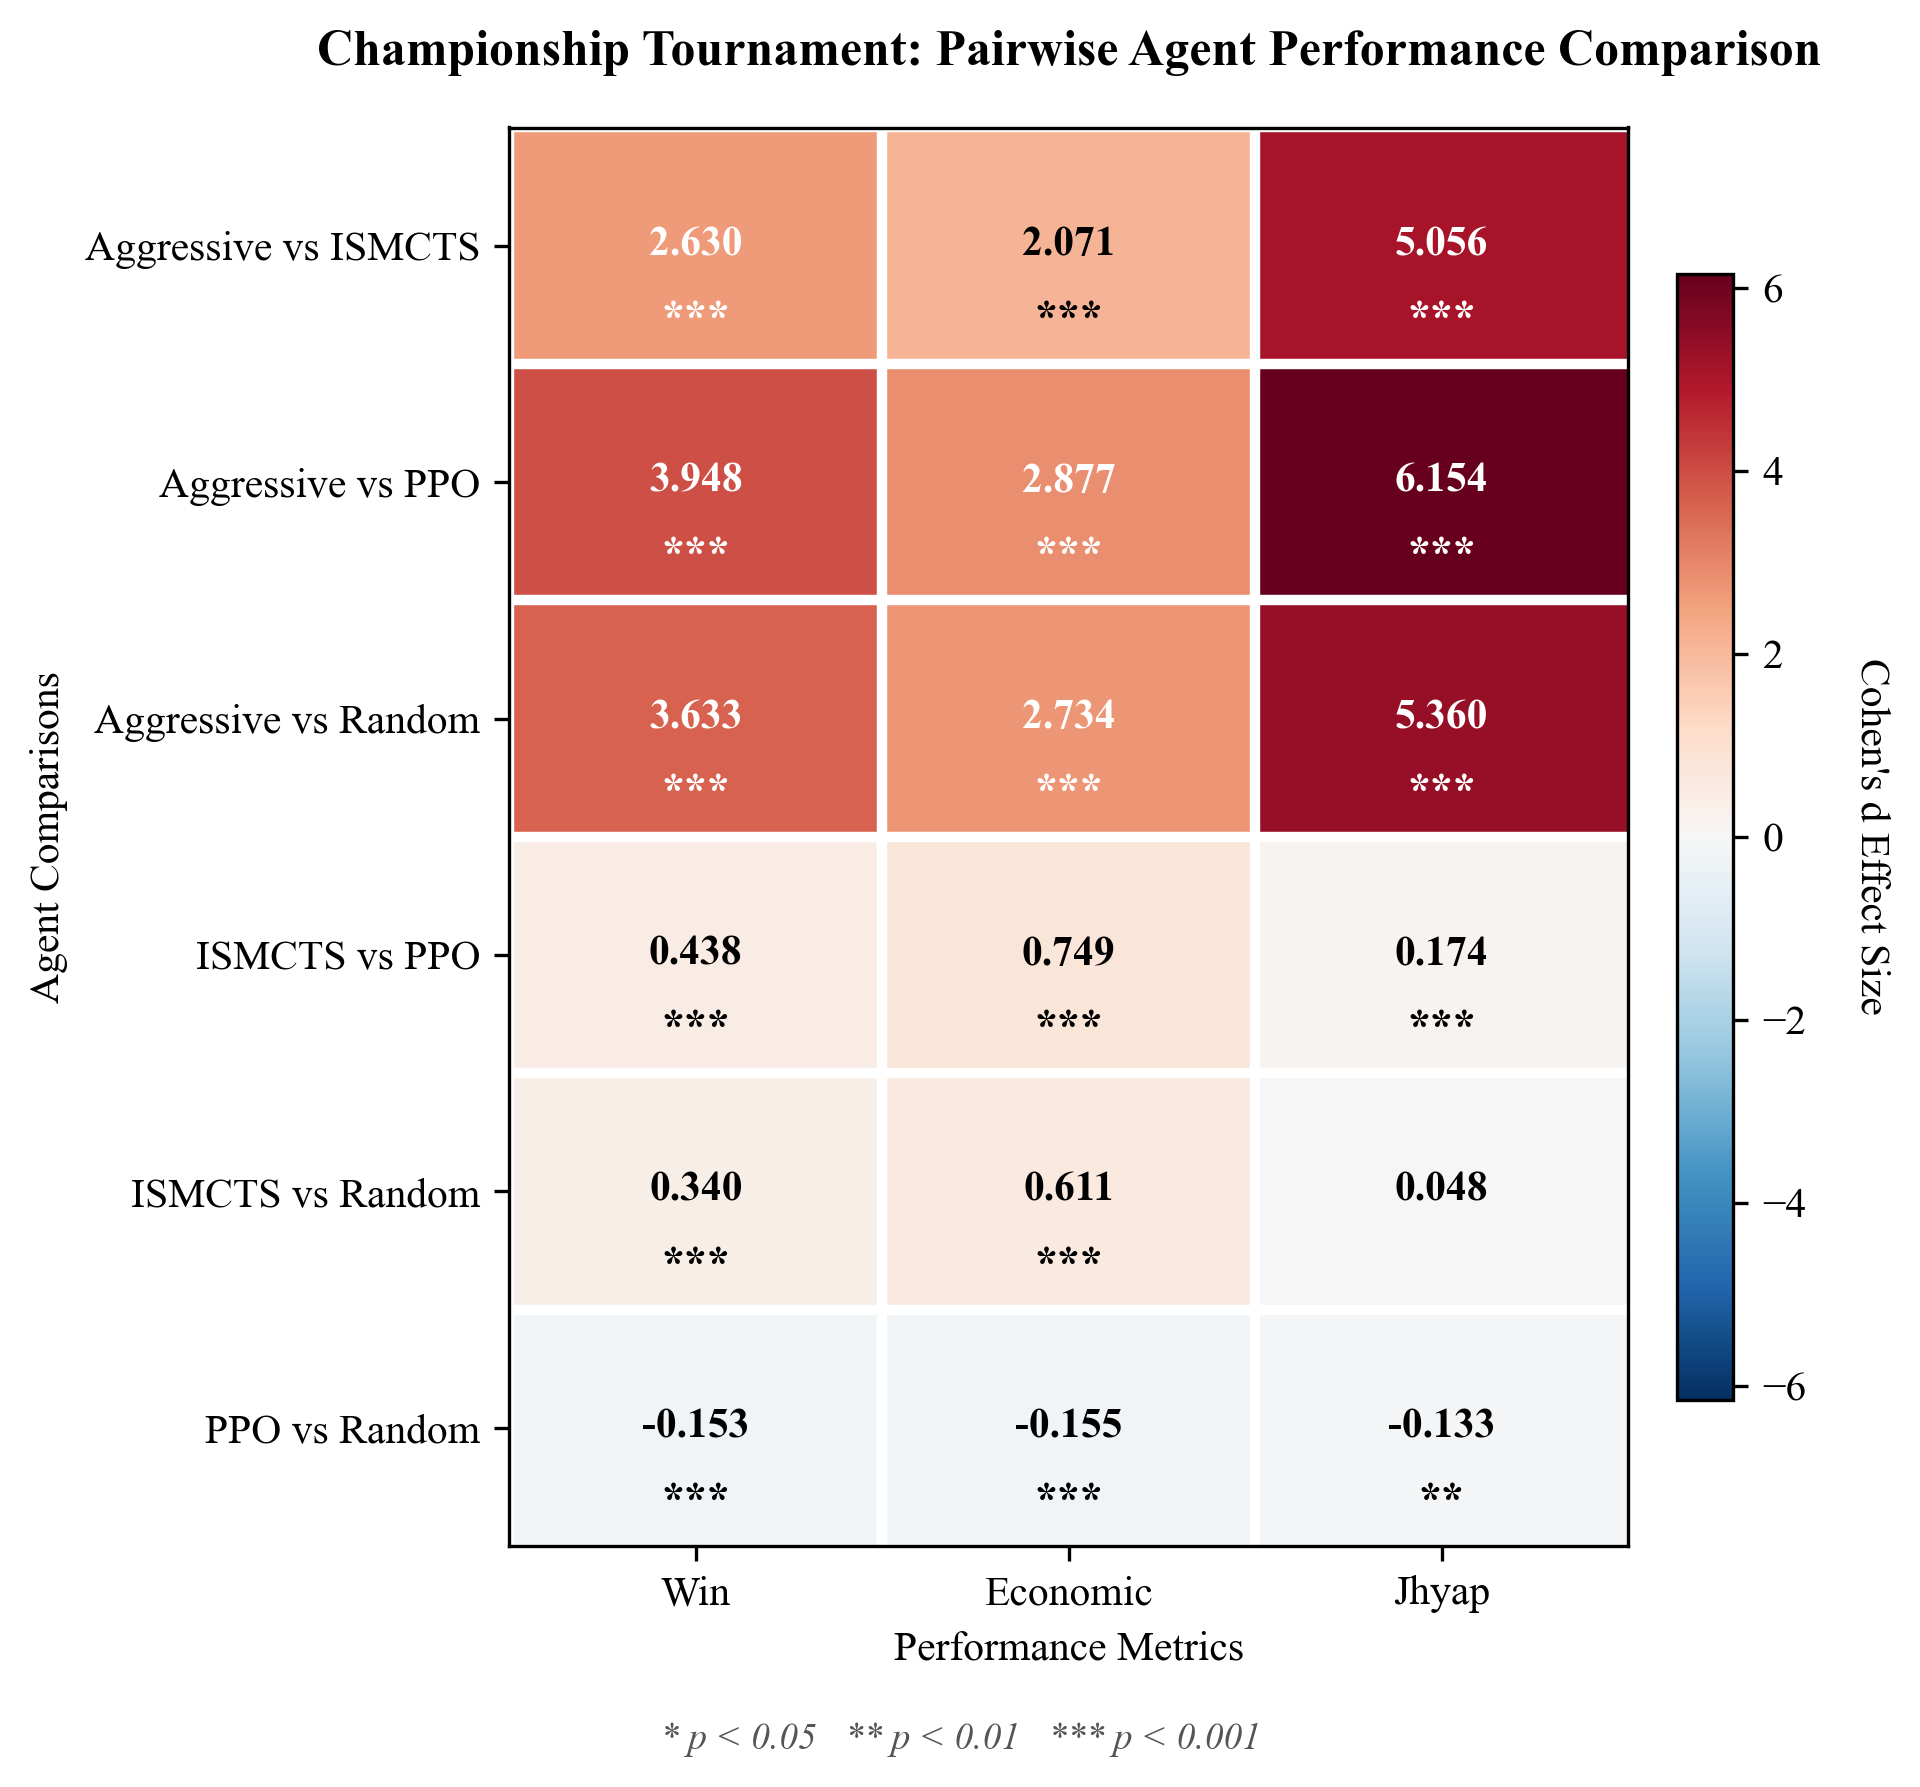

saved /Users/sahajrajmalla/Documents/dhumbal-ai/visualization/plots/championship_comparison_heatmap.png


In [44]:
# Championship pairwise Cohen's d heatmap. Source: championship/game_cohens_d_rounds_1024.csv
import csv
from matplotlib.colors import TwoSlopeNorm
metrics = ['Win', 'Economic', 'Jhyap']
comparisons, dvals, pvals = [], [], []
with open(os.path.join(ROOT, 'championship/game_cohens_d_rounds_1024.csv')) as f:
    for row in csv.DictReader(f):
        comparisons.append(row['Comparison'])
        dvals.append([float(row['Win d']), float(row['Economic d']), float(row['Jhyap d'])])
        pvals.append([float(row['Win p']), float(row['Economic p']), float(row['Jhyap p'])])
d = np.array(dvals); p = np.array(pvals)
def mark(v):
    return '***' if v < 0.001 else '**' if v < 0.01 else '*' if v < 0.05 else ''
fig, ax = plt.subplots(figsize=(6.5, 6))
vmax = max(abs(d.min()), abs(d.max())); norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
im = ax.imshow(d, cmap='RdBu_r', aspect='auto', norm=norm)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cbar.set_label("Cohen's d Effect Size", rotation=270, labelpad=20)
ax.set_xticks(range(len(metrics))); ax.set_yticks(range(len(comparisons)))
ax.set_xticklabels(metrics); ax.set_yticklabels(comparisons)
ax.set_xticks(np.arange(len(metrics))-0.5, minor=True); ax.set_yticks(np.arange(len(comparisons))-0.5, minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2.5); ax.tick_params(which='minor', size=0)
for i in range(len(comparisons)):
    for j in range(len(metrics)):
        tc = 'white' if abs(d[i, j]) > vmax*0.4 else 'black'
        ax.text(j, i, f'{d[i, j]:.3f}', ha='center', va='center', color=tc, fontsize=10, fontweight='bold')
        mk = mark(p[i, j])
        if mk: ax.text(j, i+0.32, mk, ha='center', va='center', color=tc, fontsize=11, fontweight='bold')
ax.set_xlabel('Performance Metrics'); ax.set_ylabel('Agent Comparisons')
ax.set_title('Championship Tournament: Pairwise Agent Performance Comparison', fontweight='bold', pad=15)
fig.text(0.5, 0.02, '* p < 0.05   ** p < 0.01   *** p < 0.001', ha='center', fontsize=9, style='italic', color='#555555')
plt.tight_layout(rect=[0, 0.04, 1, 1])
out = os.path.join(PLOTS, 'championship_comparison_heatmap.png')
plt.savefig(out, dpi=300, bbox_inches='tight', facecolor='white'); plt.show()
print('saved', out)
